# Thermal identification

The observer's room, air path and laminate capacity identified off its three thermometers while the board runs, the margin the envelope keeps of every span, and a trip. On the stand-in, model time only - no board, and the same on any machine.

The stand-in is a hypothetical board with a ground truth: the same twenty-node graph the board runs, in a situation - here the tour, temperate 20 C, cold -25, toasty 45, round again - read through three noisy thermometers every thirty seconds and identified by the same identifier the firmware runs (`coaxial/thermal_ident.py` mirrors `thermal/src/thermal_ident.c`). The observer is told nothing about the situation; the tour moves on when the identification has held STABLE for ten seconds of wall time. The load is the page's cycle, two model minutes at 30 A and four idle, under the envelope.

In [1]:
from coaxial.simulated.power import SimulatedThermal

board = SimulatedThermal(situation='tour')
board.load_cycle(on_s=120.0, off_s=240.0)
print('starts in', board.truth()['situation'], 'at', board.state()['ntc'], 'C')
print('rooms on the tour:', ', '.join('%s %.0f C' % (name, SimulatedThermal.SITUATIONS[name]['ambient'])
                                      for name in SimulatedThermal.TOUR))

starts in temperate at 20.0 C
rooms on the tour: temperate 20 C, cold -25 C, toasty 45 C


A walk of 150 model minutes, a row a minute. `fast_forward` drives the model's own clock, so the readers stop advancing on the wall clock and the walk reads the same wherever it runs.

In [2]:
rows = []
faces = {}
last = board.truth()['situation']
for minute in range(1, 151):
    board.fast_forward(60.0, live=True)
    st, got, truth = board.state(), board.identification(), board.truth()
    if truth['load_a']:
        faces[truth['situation']] = (minute, got['ambient'], dict(st['nodes']))   # the last loaded minute of each leg
    rows.append({'minute': minute, 'situation': truth['situation'],
                 'state': got['state'], 'margin': got['margin'],
                 'room': got['ambient'], 'room_sigma': got['ambient_sigma'],
                 'room_truth': truth['ambient'],
                 'air': got['scales']['air'], 'air_sigma': got['sigma']['air'],
                 'air_truth': truth['air'], 'innovation': got['innovation_k'],
                 'driver_u': st['nodes']['driver_u'], 'load_a': truth['load_a'] or 0.0})
    if truth['situation'] != last:
        print('minute %3d: %s -> %s' % (minute, last, truth['situation']))
        last = truth['situation']
stable = [r for r in rows if r['state'] == 'STABLE']
print('%d minutes STABLE of %d; final margin %.2f, room %.1f C for %.0f, air %.2f for %.2f'
      % (len(stable), len(rows), rows[-1]['margin'], rows[-1]['room'],
         rows[-1]['room_truth'], rows[-1]['air'], rows[-1]['air_truth']))

minute  12: temperate -> cold


minute  40: cold -> toasty


minute  70: toasty -> temperate


minute  95: temperate -> cold


minute 117: cold -> toasty


minute 143: toasty -> temperate


14 minutes STABLE of 150; final margin 0.80, room 15.4 C for 20, air 1.32 for 1.00


The margin is continuous: the record's floor while the model is doubted whole, one when not at all, and the doubt the worse of the innovation and the covariance normalised. A room step throws it to the floor within a minute; the room is reset to its prior on the way, so the step is charged to the room and not to the air path.

The board in each room under the same load, as the THERMAL OBSERVER page draws it - the last loaded minute of each leg. One fixed colour scale, so the rooms are compared by eye: the switches sit where the room puts them, and the room in the title is what the identification had found by then.

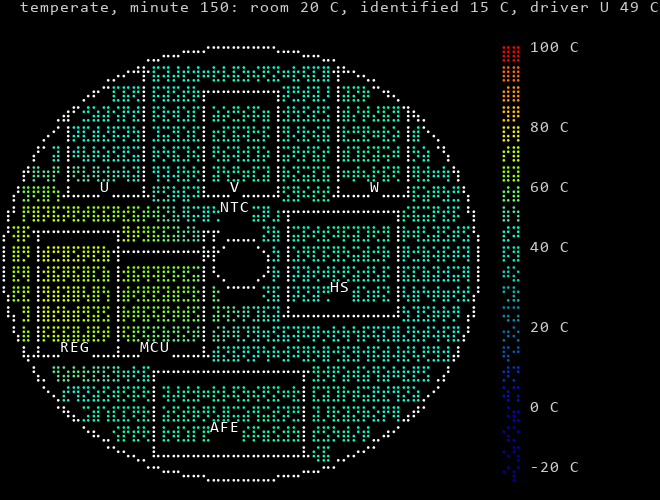

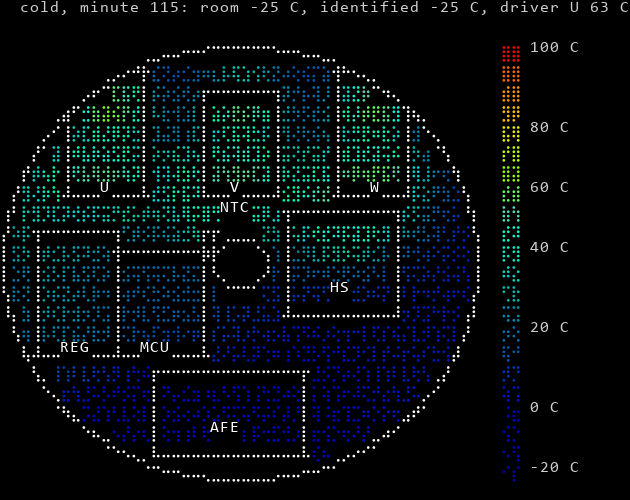

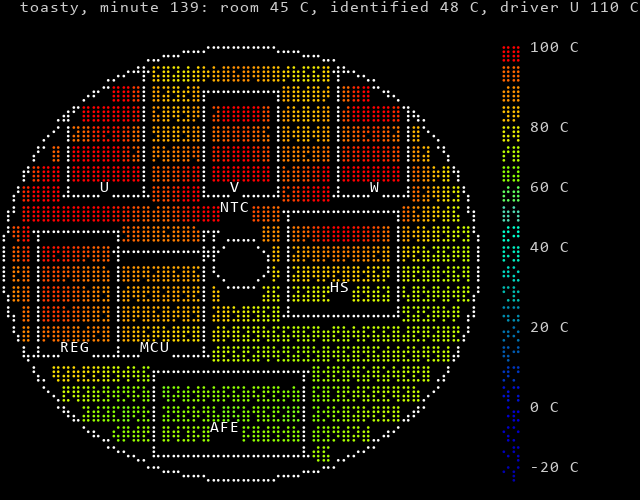

In [3]:
from coaxial import ansi, thermalmap
from coaxial.thermal import NODES
from IPython.display import display

for room in SimulatedThermal.TOUR:
    if room not in faces:
        continue
    minute, found, nodes = faces[room]
    display(ansi.image(thermalmap.render({n: nodes[n] for n in NODES}, nodes['board'], cells=48, colour=True,
                                         title='%s, minute %d: room %.0f C, identified %.0f C, driver U %.0f C'
                                               % (room, minute, SimulatedThermal.SITUATIONS[room]['ambient'], found, nodes['driver_u']))))

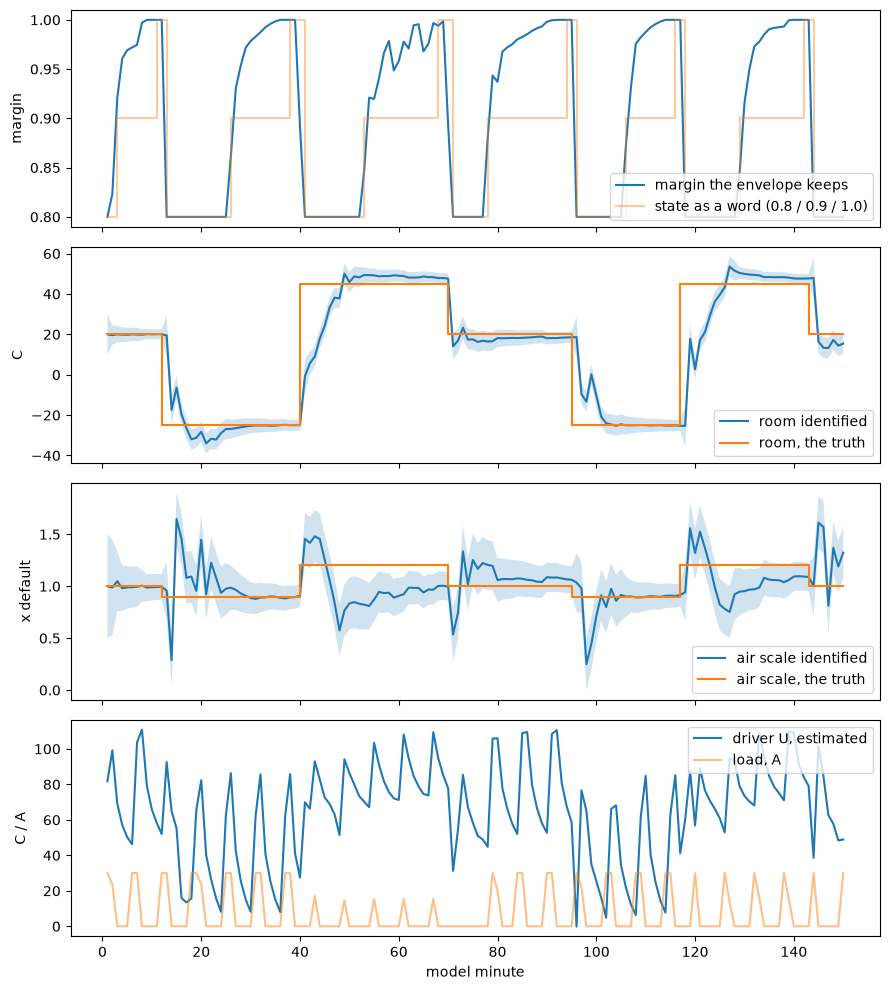

In [4]:
import matplotlib.pyplot as plt

t = [r['minute'] for r in rows]
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(9, 10))
axes[0].plot(t, [r['margin'] for r in rows], label='margin the envelope keeps')
axes[0].step(t, [{'UNCERTAIN': 0.8, 'CONVERGING': 0.9, 'STABLE': 1.0}[r['state']] for r in rows],
             where='post', alpha=0.4, label='state as a word (0.8 / 0.9 / 1.0)')
axes[0].set_ylabel('margin'); axes[0].legend(loc='lower right')
axes[1].plot(t, [r['room'] for r in rows], label='room identified')
axes[1].fill_between(t, [r['room'] - r['room_sigma'] for r in rows],
                     [r['room'] + r['room_sigma'] for r in rows], alpha=0.2)
axes[1].step(t, [r['room_truth'] for r in rows], where='post', label='room, the truth')
axes[1].set_ylabel('C'); axes[1].legend(loc='lower right')
axes[2].plot(t, [r['air'] for r in rows], label='air scale identified')
axes[2].fill_between(t, [r['air'] - r['air_sigma'] for r in rows],
                     [r['air'] + r['air_sigma'] for r in rows], alpha=0.2)
axes[2].step(t, [r['air_truth'] for r in rows], where='post', label='air scale, the truth')
axes[2].set_ylabel('x default'); axes[2].legend(loc='lower right')
axes[3].plot(t, [r['driver_u'] for r in rows], label='driver U, estimated')
axes[3].plot(t, [r['load_a'] for r in rows], alpha=0.5, label='load, A')
axes[3].set_ylabel('C / A'); axes[3].set_xlabel('model minute'); axes[3].legend(loc='upper right')
plt.tight_layout(); plt.show()

## A trip

A trip is the ceiling reached with the throttle already acting. After one the margin is held at 0.70 of every span and given back a percent a minute - half an hour to the identification's own - and the stage runs on less until then. Re-arming is the host's.

In [5]:
cold = SimulatedThermal(situation='cold')
armed = [True]

def drop_stage():
    if not armed[0]:
        return False
    armed[0] = False
    return True

cold._gate = drop_stage
cooked = {'amps': (200.0, 200.0, 200.0), 'switching': True}
idle = {'amps': (0.0, 0.0, 0.0), 'switching': False}
trace = []
for minute in range(1, 41):
    cold.fast_forward(60.0, seen=cooked if minute <= 2 else idle, live=True)
    b, got = cold.budget(), cold.identification()
    trace.append((minute, got['margin'], b['worst'], b['trips']))
    if minute in (1, 2, 3, 5, 10, 20, 30, 40):
        print('minute %2d: trips %d, worst %.2f of the span in force, margin %.2f'
              % (minute, b['trips'], b['worst'], got['margin']))

minute  1: trips 1, worst 1.00 of the span in force, margin 0.71
minute  2: trips 1, worst 1.00 of the span in force, margin 0.72


minute  3: trips 1, worst 1.00 of the span in force, margin 0.73


minute  5: trips 1, worst 1.00 of the span in force, margin 0.75


minute 10: trips 1, worst 1.00 of the span in force, margin 0.80


minute 20: trips 1, worst 1.00 of the span in force, margin 0.90


minute 30: trips 1, worst 1.00 of the span in force, margin 1.00


minute 40: trips 1, worst 0.59 of the span in force, margin 1.00


## Conclusions

In [6]:
moves = [r['minute'] for a, r in zip(rows, rows[1:]) if a['situation'] != r['situation']]
print('the tour moved at model minutes', moves)
print('STABLE %d of %d minutes - the tour moves on 100 s of it, so it never lasts; '
      'the margin at the floor %d minutes, whole %d'
      % (len(stable), len(rows), sum(1 for r in rows if r['margin'] <= 0.8 + 1e-9),
         sum(1 for r in rows if r['margin'] >= 0.999)))
before = [rows[m - 2] for m in moves]          # the minute before each move: STABLE, the leg settled
print('the room at the end of each leg: ' + ', '.join(
    '%.1f for %.0f' % (r['room'], r['room_truth']) for r in before))
print("worst room error at a settled leg's end: %.1f K"
      % max(abs(r['room'] - r['room_truth']) for r in before))
print('the trip: margin %.2f the minute after, %.2f at minute 20, %.2f at 40'
      % (trace[2][1], trace[19][1], trace[39][1]))

the tour moved at model minutes [12, 40, 70, 95, 117, 143]
STABLE 14 of 150 minutes - the tour moves on 100 s of it, so it never lasts; the margin at the floor 61 minutes, whole 22
the room at the end of each leg: 20.1 for 20, -25.0 for -25, 47.9 for 45, 18.5 for 20, -25.1 for -25, 47.6 for 45
worst room error at a settled leg's end: 2.9 K
the trip: margin 0.73 the minute after, 0.90 at minute 20, 1.00 at 40
